# Obtencion de datos


In [3]:
import pandas as pd
import numpy as np


In [ ]:
df=pd.read_csv("empleados.csv")# por defecto separa por comas.
df.head()

,id_empleado;nombre;departamento;salario
0,1;Ana;IT;1200
1,2;Luis;Ventas;1000
2,3;María;IT;1200
3,4;Pedro;Marketing;1100
4,5;Sofía;Ventas;1050


In [3]:
df=pd.read_csv("empleados.csv",sep=";")# si el separador es otro, se debe indicar.
df.head()

,id_empleado,nombre,departamento,salario
0,1,Ana,IT,1200
1,2,Luis,Ventas,1000
2,3,María,IT,1200
3,4,Pedro,Marketing,1100
4,5,Sofía,Ventas,1050


In [6]:
# sin encabezado
df=pd.read_csv("empleados_sh.csv",sep=";") # si no tiene encabezado se pierde el primer dato de la fila 1
df.head()

,1,Ana,IT,1200
0,2,Luis,Ventas,1000
1,3,María,IT,1300
2,4,Pedro,Marketing,1100
3,5,Sofía,Ventas,1050
4,6,Carlos,IT,1400


In [24]:
df=pd.read_csv('empleados_sh.csv',sep=';',header=None) # si no tiene encabezado se debe indicar que no hay encabezado.
df.head()

,0,1,2,3
0,1,Ana,IT,1200
1,2,Luis,Ventas,1000
2,3,María,IT,1300
3,4,Pedro,Marketing,1100
4,5,Sofía,Ventas,1050


In [4]:
df=pd.read_csv("empleados_sh.csv",sep=";",header=None,names=["Nombre","Area trabajo","Salario"]) # se pueden asignar nombres a las columnas.
df.head()

,Nombre,Area trabajo,Salario
1,Ana,IT,1200
2,Luis,Ventas,1000
3,María,IT,1300
4,Pedro,Marketing,1100
5,Sofía,Ventas,1050


In [5]:
df.loc[1, "Salario"] = "no disponible" #df.loc[fila, "columna"] = valor 
print(df.head())


  Nombre Area trabajo        Salario
1    Ana           IT  no disponible
2   Luis       Ventas           1000
3  María           IT           1300
4  Pedro    Marketing           1100
5  Sofía       Ventas           1050


C:\Users\l\AppData\Local\Temp\ipykernel_28256\728985154.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'no disponible' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df.loc[1, "Salario"] = "no disponible" #df.loc[fila, "columna"] = valor


In [8]:
df.to_csv("empleados_NAN.csv",sep=";",index=True) # se puede guardar el dataframe con valores NA, indicando el separador y si se desea guardar el índice.

In [9]:
#asumir un NA
df=pd.read_csv("empleados_NAN.csv",sep=";",na_values=["no disponible","?","N/A","NA"]) # los valores se hacen NaN
df.head()

,Unnamed: 0.1,Unnamed: 0,Nombre,Area trabajo,Salario
0,0,1,Ana,IT,NaN
1,1,2,Luis,Ventas,1000.0
2,2,3,María,IT,1300.0
3,3,4,Pedro,Marketing,1100.0
4,4,5,Sofía,Ventas,1050.0


In [81]:
print(df.isna()) # se obtiene un dataframe con True en las posiciones donde hay NaN y False donde no hay NaN.
print(df.isnull()) # es lo mismo que isna().
print(df.isna().sum()) # se obtiene la cantidad de valores NaN por columna.

   Nombre  Area trabajo  Salario
0   False         False     True
1   False         False    False
2   False         False    False
3   False         False    False
4   False         False    False
5   False         False    False
6   False         False    False
7   False         False    False
8   False         False    False
9   False         False    False
   Nombre  Area trabajo  Salario
0   False         False     True
1   False         False    False
2   False         False    False
3   False         False    False
4   False         False    False
5   False         False    False
6   False         False    False
7   False         False    False
8   False         False    False
9   False         False    False
Nombre          0
Area trabajo    0
Salario         1
dtype: int64


In [92]:
#eliminar filas con valores faltantea
df_sin_na=df.dropna() # se eliminan las filas que tienen al menos un NaN.
print(df_sin_na)
print("--------------df_sin_na----------------")
df_relleno=df.fillna(0) # se rellenan los NaN con un valor específico.
print(df_relleno)
print("------------df_relleno------------------")



      Nombre Area trabajo  Salario
1       Luis       Ventas   1000.0
2      María           IT   1300.0
3      Pedro    Marketing   1100.0
4      Sofía       Ventas   1050.0
5     Carlos           IT   1400.0
6      Lucía    Marketing   1150.0
7      Jorge       Ventas    980.0
8  Valentina           IT   1500.0
9      Diego    Marketing   1080.0
--------------df_sin_na----------------
      Nombre Area trabajo  Salario
0        Ana           IT      0.0
1       Luis       Ventas   1000.0
2      María           IT   1300.0
3      Pedro    Marketing   1100.0
4      Sofía       Ventas   1050.0
5     Carlos           IT   1400.0
6      Lucía    Marketing   1150.0
7      Jorge       Ventas    980.0
8  Valentina           IT   1500.0
9      Diego    Marketing   1080.0
------------df_relleno------------------


In [94]:
print(df)

print("---------------df---------------")


df_relleno2 = df.fillna(df.mean(numeric_only=True)) # se rellenan los NaN con la media de la columna, solo para columnas numéricas.
print(df_relleno2.head())
print("---------------df_relleno2---------------")


      Nombre Area trabajo  Salario
0        Ana           IT      NaN
1       Luis       Ventas   1000.0
2      María           IT   1300.0
3      Pedro    Marketing   1100.0
4      Sofía       Ventas   1050.0
5     Carlos           IT   1400.0
6      Lucía    Marketing   1150.0
7      Jorge       Ventas    980.0
8  Valentina           IT   1500.0
9      Diego    Marketing   1080.0
---------------df---------------
  Nombre Area trabajo      Salario
0    Ana           IT  1173.333333
1   Luis       Ventas  1000.000000
2  María           IT  1300.000000
3  Pedro    Marketing  1100.000000
4  Sofía       Ventas  1050.000000
---------------df_relleno2---------------


In [49]:
#completar NaN con un valor específico
df["Salario"] = df["Salario"].fillna("sin información")
print(df.head())

  Nombre Area trabajo          Salario
0    Ana           IT  sin información
1   Luis       Ventas           1000.0
2  María           IT           1300.0
3  Pedro    Marketing           1100.0
4  Sofía       Ventas           1050.0


In [51]:
df["Salario"] = df["Salario"].fillna(df["Salario"].mean())
print(df.head())

  Nombre Area trabajo      Salario
0    Ana           IT  1173.333333
1   Luis       Ventas  1000.000000
2  María           IT  1300.000000
3  Pedro    Marketing  1100.000000
4  Sofía       Ventas  1050.000000


In [ ]:
ventas=pd.read_excel("ventas.xlsx") # por defecto lee la primera hoja, si el excel tiene varias hojas se puede especificar el nombre o el número de la hoja.
print(ventas.head()) 

   id_empleado  region  ventas_mensuales
0            1   Norte              5000
1            2     Sur              4200
2            3   Norte              6100
3            4  Centro              4800
4            5     Sur              4500


In [57]:
#revisar excel con mas de una hoja
ventas1=pd.read_excel("ventas.xlsx",sheet_name="Ventas_2025") # se puede especificar el nombre de la hoja
ventas11=pd.read_excel("ventas.xlsx",sheet_name=0) # se puede especificar el número de la hoja, empezando desde 0
ventas2=pd.read_excel("ventas.xlsx",sheet_name="Ventas_2026") # se puede especificar el nombre de la hoja
print(ventas1.head())  
print(ventas11.head())
print(ventas2.head())     

   id_empleado  region  ventas_mensuales
0            1   Norte              5000
1            2     Sur              4200
2            3   Norte              6100
3            4  Centro              4800
4            5     Sur              4500
   id_empleado  region  ventas_mensuales
0            1   Norte              5000
1            2     Sur              4200
2            3   Norte              6100
3            4  Centro              4800
4            5     Sur              4500
   id_empleado  region  ventas_mensuales
0            1   Norte              1000
1            2     Sur              5500
2            3   Norte              5233
3            4  Centro              4560


In [64]:
url="https://es.wikipedia.org/wiki/Regiones_de_Chile"

tablas = pd.read_html(url,storage_options={'User-Agent': 'Mozilla/5.0'}) # se pueden revisar las tablas que hay en la página, indicando un user-agent para evitar bloqueos.
print(len(tablas)) # se puede revisar cuántas tablas se encontraron.

5


In [ ]:
tablas[0]# se puede revisar la primera tabla encontrada. variar 0-1-2-3-4-5-6-7-8-9 dependiendo de la cantidad de tablas encontradas.

,Región,Región.1,Región.2
0,Provincia (1928-1974),Provincia (1928-1974),Provincia (1928-1974)
1,Arica y Parinacota Tarapacá Antofagasta Atacam...,Arica y Parinacota Tarapacá Antofagasta Atacam...,Arica y Parinacota Tarapacá Antofagasta Atacam...
2,País,Chile,Chile
3,Creados por,Junta Militar de Gobierno,Junta Militar de Gobierno
4,Fecha de creación,1974,1974
5,Datos estadísticos,Datos estadísticos,Datos estadísticos
6,Número actual,16 (a partir de 2017),16 (a partir de 2017)
7,Gobierno,Gobierno Regional,Gobierno Regional
8,Subdivisión(es),Provincia Comuna,Provincia Comuna
9,[editar datos en Wikidata],[editar datos en Wikidata],[editar datos en Wikidata]


In [67]:
tablas[1]

,Regiones Corfo,Provincias (hasta 1976),Regiones actuales (desde 2018)
0,Norte Grande,Tarapacá y Antofagasta,"Arica y Parinacota, Tarapacá y Antofagasta"
1,Norte Chico,Atacama y Coquimbo,Atacama y Coquimbo
2,Núcleo Central,"Aconcagua, Valparaíso, Santiago, O'Higgins, Co...","Valparaíso, Metropolitana de Santiago, O'Higgi..."
3,Concepción y La Frontera,"Concepción, Arauco, Biobío, Malleco y Cautín",Biobío y La Araucanía
4,Región de los Lagos,"Valdivia, Osorno y Llanquihue",Los Ríos y Los Lagos (continental)
5,Región de los Canales,"Chiloé, Aysén y Magallanes","Los Lagos (Provincia de Chiloé), Aysén y Magal..."
6,NaN,NaN,NaN


<Axes: >

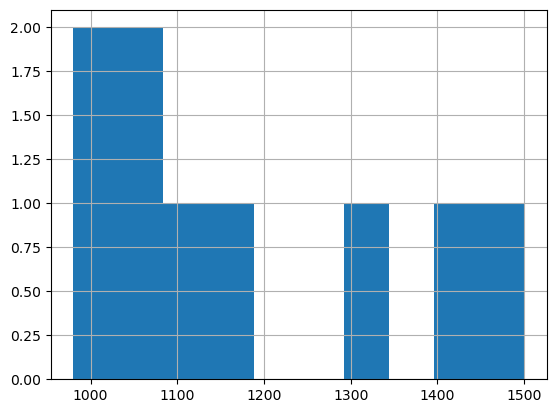

In [96]:
#visualizar tablas con pandas
df['Salario'].hist()

<Axes: ylabel='Frequency'>

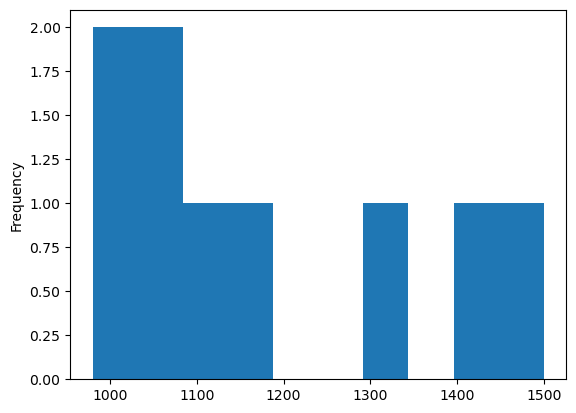

In [98]:
df['Salario'].plot(kind='hist', y='Salario')